In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Paths (repo-relative)
RESULTS_DIR = Path("../results")
FIG_DIR = RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

METRICS_PATH = RESULTS_DIR / "classification_metrics.csv"

print("RESULTS_DIR:", RESULTS_DIR.resolve())
print("FIG_DIR:", FIG_DIR.resolve())
print("METRICS_PATH exists:", METRICS_PATH.exists())

# Load classification metrics
metrics = pd.read_csv(METRICS_PATH)

print("\nLoaded classification metrics:")
print("Shape:", metrics.shape)
print("Columns:", list(metrics.columns))
display(metrics.head(10))

RESULTS_DIR: D:\University of Bicocca\Data science\2nd year 2025-26\1st Semester\Text Mining & Search\Project\drug-review-sentiment-topic-modeling\results
FIG_DIR: D:\University of Bicocca\Data science\2nd year 2025-26\1st Semester\Text Mining & Search\Project\drug-review-sentiment-topic-modeling\results\figures
METRICS_PATH exists: True

Loaded classification metrics:
Shape: (3, 9)
Columns: ['representation', 'model', 'n_train', 'n_test', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'notes']


,representation,model,n_train,n_test,accuracy,precision_macro,recall_macro,f1_macro,notes
0,TF-IDF,LogisticRegression,39998,10000,0.8529,0.811945,0.847009,0.825427,sparse
1,TF-IDF,LinearSVM,39998,10000,0.8498,0.808186,0.836098,0.819627,sparse
2,BERT,LogisticRegression,39998,10000,0.7370,0.697786,0.737605,0.704243,dense (no fine-tuning)


In [2]:
#Clean Classification Comparison Table + Highlight Winner
# Select relevant columns
comparison = metrics[[
    "representation",
    "model",
    "accuracy",
    "f1_macro",
    "precision_macro",
    "recall_macro"
]].copy()

# Sort by Macro F1 (descending)
comparison = comparison.sort_values(by="f1_macro", ascending=False).reset_index(drop=True)

print("===== CLASSIFICATION COMPARISON (Sorted by Macro F1) =====")
display(comparison)

# Identify winner
best_row = comparison.iloc[0]

print("\n===== BEST MODEL =====")
print(f"Representation: {best_row['representation']}")
print(f"Model: {best_row['model']}")
print(f"Macro F1: {best_row['f1_macro']:.4f}")
print(f"Accuracy: {best_row['accuracy']:.4f}")

===== CLASSIFICATION COMPARISON (Sorted by Macro F1) =====


,representation,model,accuracy,f1_macro,precision_macro,recall_macro
0,TF-IDF,LogisticRegression,0.8529,0.825427,0.811945,0.847009
1,TF-IDF,LinearSVM,0.8498,0.819627,0.808186,0.836098
2,BERT,LogisticRegression,0.7370,0.704243,0.697786,0.737605



===== BEST MODEL =====
Representation: TF-IDF
Model: LogisticRegression
Macro F1: 0.8254
Accuracy: 0.8529


In [6]:
# ---- Reload dataset for coherence computation ----
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/processed/reviews_preprocessed.csv")
df = pd.read_csv(DATA_PATH)

print("Loaded df:", df.shape)

Loaded df: (49998, 5)


In [8]:
#Compute LDA Coherence (NPMI)


import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

# 1) Vectorize (same settings you used in Phase 7 for comparability)
vectorizer = CountVectorizer(min_df=20, max_df=0.5)
X_counts_all = vectorizer.fit_transform(df["clean_review"].astype(str))
vocab = vectorizer.get_feature_names_out()

print("DTM shape:", X_counts_all.shape, "| vocab:", len(vocab))

# 2) Fit LDA (ALL)
k = 10
lda_all = LatentDirichletAllocation(
    n_components=k,
    random_state=42,
    learning_method="batch",
    max_iter=10
)
lda_all.fit(X_counts_all)
print("LDA fitted (ALL). k =", k)

# 3) Build topics (top 10 words each)
TOP_N = 10
lda_topics = []
for topic_id in range(k):
    topic = lda_all.components_[topic_id]
    top_idx = topic.argsort()[-TOP_N:][::-1]
    words = [vocab[i] for i in top_idx]
    lda_topics.append(words)

# 4) Tokenized texts + dictionary (use same clean_review column)
texts = [doc.split() for doc in df["clean_review"].astype(str)]
dictionary = Dictionary(texts)

# 5) NPMI coherence
coherence_lda_all = CoherenceModel(
    topics=lda_topics,
    texts=texts,
    dictionary=dictionary,
    coherence="c_npmi"
).get_coherence()

print("LDA (ALL) NPMI:", round(coherence_lda_all, 4))

DTM shape: (49998, 4517) | vocab: 4517
LDA fitted (ALL). k = 10
LDA (ALL) NPMI: 0.0139


In [9]:
# (compute coherence for POS and NEG, same k and same vectorizer settings
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

k = 10
TOP_N = 10

# Split
df_pos = df[df["sentiment"] == 1].copy()
df_neg = df[df["sentiment"] == 0].copy()

# Tokenized texts + dictionaries per split (important for correct NPMI)
texts_pos = [doc.split() for doc in df_pos["clean_review"].astype(str)]
texts_neg = [doc.split() for doc in df_neg["clean_review"].astype(str)]
dict_pos = Dictionary(texts_pos)
dict_neg = Dictionary(texts_neg)

# Vectorize + fit LDA (POS)
vec_pos = CountVectorizer(min_df=20, max_df=0.5)
X_pos = vec_pos.fit_transform(df_pos["clean_review"].astype(str))
vocab_pos = vec_pos.get_feature_names_out()

lda_pos = LatentDirichletAllocation(n_components=k, random_state=42, learning_method="batch", max_iter=10)
lda_pos.fit(X_pos)

topics_pos = []
for t in range(k):
    top_idx = lda_pos.components_[t].argsort()[-TOP_N:][::-1]
    topics_pos.append([vocab_pos[i] for i in top_idx])

npmi_pos = CoherenceModel(topics=topics_pos, texts=texts_pos, dictionary=dict_pos, coherence="c_npmi").get_coherence()

# Vectorize + fit LDA (NEG)
vec_neg = CountVectorizer(min_df=20, max_df=0.5)
X_neg = vec_neg.fit_transform(df_neg["clean_review"].astype(str))
vocab_neg = vec_neg.get_feature_names_out()

lda_neg = LatentDirichletAllocation(n_components=k, random_state=42, learning_method="batch", max_iter=10)
lda_neg.fit(X_neg)

topics_neg = []
for t in range(k):
    top_idx = lda_neg.components_[t].argsort()[-TOP_N:][::-1]
    topics_neg.append([vocab_neg[i] for i in top_idx])

npmi_neg = CoherenceModel(topics=topics_neg, texts=texts_neg, dictionary=dict_neg, coherence="c_npmi").get_coherence()

print("LDA (POS) NPMI:", round(npmi_pos, 4))
print("LDA (NEG) NPMI:", round(npmi_neg, 4))

print("POS DTM:", X_pos.shape, " | vocab:", len(vocab_pos))
print("NEG DTM:", X_neg.shape, " | vocab:", len(vocab_neg))

LDA (POS) NPMI: 0.0136
LDA (NEG) NPMI: 0.0188
POS DTM: (36324, 3857)  | vocab: 3857
NEG DTM: (13674, 2091)  | vocab: 2091


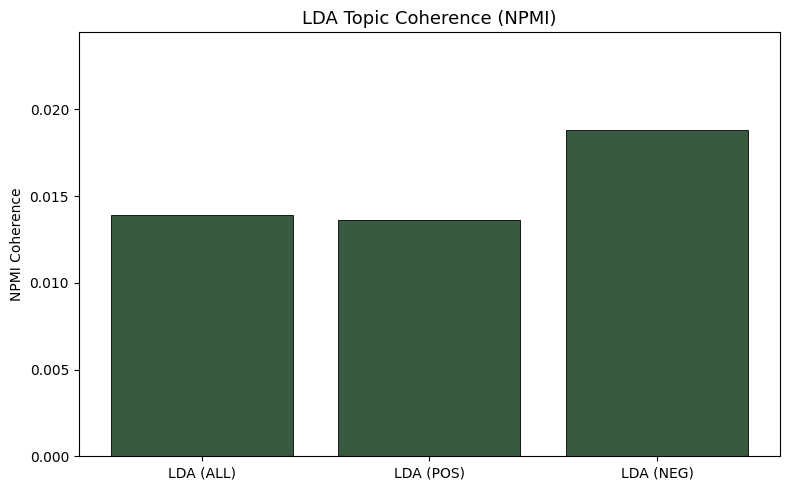

Saved: ..\results\figures\fig_eval_coherence_lda.png


In [10]:
# Build LDA Coherence Comparison Plot
import matplotlib.pyplot as plt

lda_all_npmi = 0.0139
lda_pos_npmi = 0.0136
lda_neg_npmi = 0.0188

labels = ["LDA (ALL)", "LDA (POS)", "LDA (NEG)"]
values = [lda_all_npmi, lda_pos_npmi, lda_neg_npmi]

plt.figure(figsize=(8,5))

plt.bar(
    labels,
    values,
    color="#3A5A40",
    edgecolor="black",
    linewidth=0.6
)

plt.ylabel("NPMI Coherence")
plt.title("LDA Topic Coherence (NPMI)", fontsize=13)
plt.ylim(0, max(values)*1.3)

plt.tight_layout()

out_path = FIG_DIR / "fig_eval_coherence_lda.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [12]:
#Compute BERTopic Coherence (ALL, POS, NEG)


import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from bertopic import BERTopic

# Reload embeddings
import numpy as np
from pathlib import Path

EMB_PATH = Path("../data/features/bert_embeddings.npy")
embeddings = np.load(EMB_PATH)

RANDOM_STATE = 42
N_SAMPLE = 5000
N_TOPICS = 15

df_reset = df.reset_index(drop=True)

# Stratified sample
idx_pos = df_reset[df_reset["sentiment"] == 1].index.to_numpy()
idx_neg = df_reset[df_reset["sentiment"] == 0].index.to_numpy()

n_pos = int(round(N_SAMPLE * (len(idx_pos) / len(df_reset))))
n_neg = N_SAMPLE - n_pos

rng = np.random.default_rng(RANDOM_STATE)
s_pos = rng.choice(idx_pos, size=min(n_pos, len(idx_pos)), replace=False)
s_neg = rng.choice(idx_neg, size=min(n_neg, len(idx_neg)), replace=False)

sample_idx = np.concatenate([s_pos, s_neg])
rng.shuffle(sample_idx)

docs_all = df_reset.loc[sample_idx, "clean_review"].astype(str).tolist()
emb_all = embeddings[sample_idx].astype(np.float32)

# PCA + KMeans
pca_model = PCA(n_components=5, random_state=RANDOM_STATE)
kmeans_model = KMeans(n_clusters=N_TOPICS, random_state=RANDOM_STATE, n_init=10)

topic_model_all = BERTopic(
    umap_model=pca_model,
    hdbscan_model=kmeans_model,
    calculate_probabilities=False,
    verbose=False
)

topics_all, _ = topic_model_all.fit_transform(docs_all, emb_all)

print("BERTopic (ALL). Topics:", len(set(topics_all)))

  File "C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 546, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1022, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1491, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

BERTopic (ALL). Topics: 15


In [13]:
# BERTopic (ALL) coherence (NPMI)
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
import numpy as np

# tokenized docs
texts_all_bt = [doc.split() for doc in docs_all]
dict_all_bt = Dictionary(texts_all_bt)

# extract top-10 words per topic
topic_ids = sorted(set(topics_all))
topics_all_bt = []
for tid in topic_ids:
    words = topic_model_all.get_topic(tid)
    if words is None:
        continue
    topics_all_bt.append([w for w, _ in words[:10]])

coherence_bt_all = CoherenceModel(
    topics=topics_all_bt,
    texts=texts_all_bt,
    dictionary=dict_all_bt,
    coherence="c_npmi"
).get_coherence()

print("BERTopic (ALL) NPMI:", round(coherence_bt_all, 4))
print("n_topics used in coherence:", len(topics_all_bt))

BERTopic (ALL) NPMI: 0.0251
n_topics used in coherence: 15


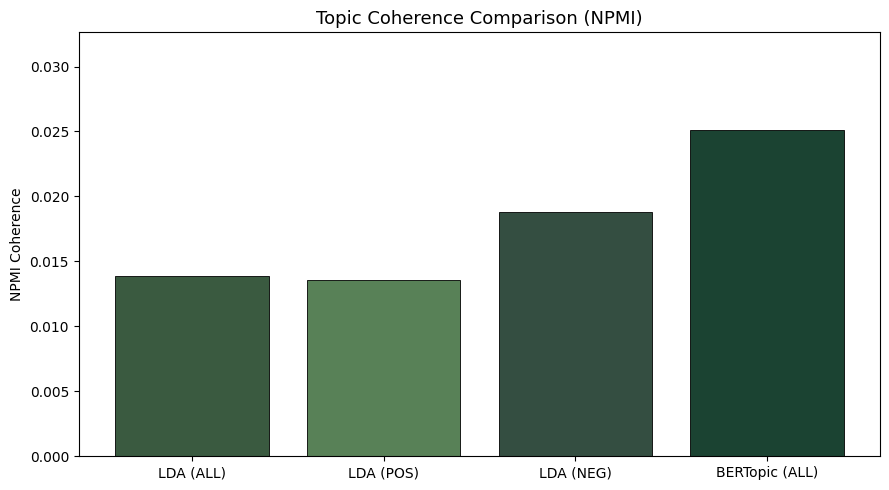

Saved: ..\results\figures\fig_eval_coherence_npmi.png


In [14]:
# Final Coherence Comparison (LDA vs BERTopic)
import matplotlib.pyplot as plt

# Values
lda_all = 0.0139
lda_pos = 0.0136
lda_neg = 0.0188
bt_all = 0.0251

labels = ["LDA (ALL)", "LDA (POS)", "LDA (NEG)", "BERTopic (ALL)"]
values = [lda_all, lda_pos, lda_neg, bt_all]

plt.figure(figsize=(9,5))

plt.bar(
    labels,
    values,
    color=["#3A5A40", "#588157", "#344E41", "#1B4332"],
    edgecolor="black",
    linewidth=0.6
)

plt.ylabel("NPMI Coherence")
plt.title("Topic Coherence Comparison (NPMI)", fontsize=13)

plt.ylim(0, max(values)*1.3)
plt.tight_layout()

out_path = FIG_DIR / "fig_eval_coherence_npmi.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

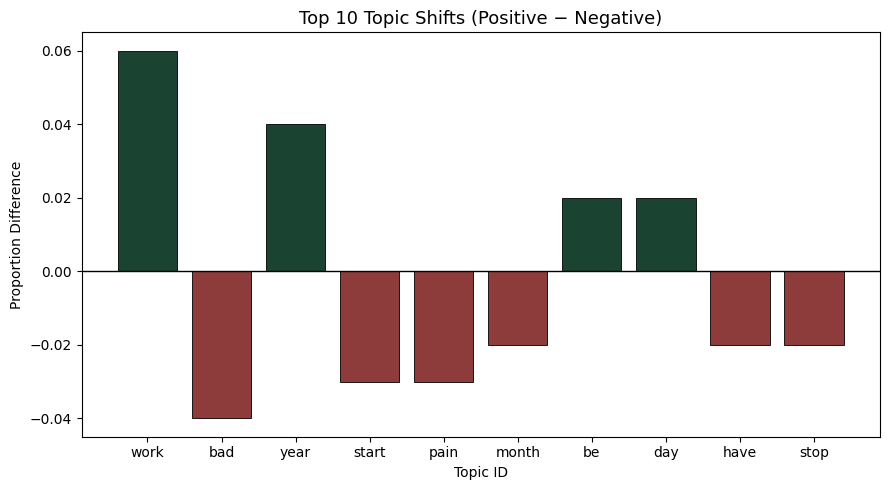

In [20]:
# Compute POS vs NEG Topic Distribution Difference (BERTopic)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure flat arrays
topics_pos_arr = np.array(topics_pos).flatten()
topics_neg_arr = np.array(topics_neg).flatten()

pos_counts = pd.Series(topics_pos_arr).value_counts()
neg_counts = pd.Series(topics_neg_arr).value_counts()

# Align topics
all_topics = sorted(set(pos_counts.index) | set(neg_counts.index))

pos_prop = np.array([pos_counts.get(t, 0) for t in all_topics])
neg_prop = np.array([neg_counts.get(t, 0) for t in all_topics])

pos_prop = pos_prop / pos_prop.sum()
neg_prop = neg_prop / neg_prop.sum()

diff = pos_prop - neg_prop

# Create dataframe
df_shift = pd.DataFrame({
    "topic": all_topics,
    "shift": diff
})

# Keep top 10 strongest shifts
df_shift["abs_shift"] = df_shift["shift"].abs()
df_shift = df_shift.sort_values("abs_shift", ascending=False).head(10)

plt.figure(figsize=(9,5))

colors = ["#1B4332" if v > 0 else "#8D3B3B" for v in df_shift["shift"]]

plt.bar(
    df_shift["topic"],
    df_shift["shift"],
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Top 10 Topic Shifts (Positive − Negative)", fontsize=13)
plt.xlabel("Topic ID")
plt.ylabel("Proportion Difference")

plt.tight_layout()

out_path = FIG_DIR / "fig_eval_topics_posneg_shift.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# Rebuild Best Classifier + Confusion Matrix
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np

# Recreate binary split (same random_state)
X = df["clean_review"].astype(str)
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# TF-IDF
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Logistic Regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_tfidf, y_train)

y_pred = clf.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

Confusion Matrix:
[[1732 1003]
 [ 352 6913]]

TN: 1732
FP: 1003
FN: 352
TP: 6913
